# IMPORT LIBRARY

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
max_model= pd.read_csv("/content/drive/MyDrive/EUPHORIAGENX_PROJECT/CLIMATE_DATASET/cesm_t2max_o3.csv")
mean_model= pd.read_csv("/content/drive/MyDrive/EUPHORIAGENX_PROJECT/CLIMATE_DATASET/cesm_t2mean_pm.csv")
max= pd.read_csv("/content/drive/MyDrive/EUPHORIAGENX_PROJECT/CLIMATE_DATASET/cm3_t2max_o3.csv")
mean= pd.read_csv("/content/drive/MyDrive/EUPHORIAGENX_PROJECT/CLIMATE_DATASET/cm3_t2mean_pm.csv")
grid= pd.read_csv("/content/drive/MyDrive/EUPHORIAGENX_PROJECT/CLIMATE_DATASET/grid.csv")

# Clean the cm3 Model based Data

In [ ]:
mean.head()

,Unnamed: 0,COL,ROW,cm3.2000.t2mean,cm3.pm.2000.ei11,cm3.pm.2000.ei40,cm3.2030.t2mean,cm3.pm.2030.ei11,cm3.pm.2030.ei40,cm3.2050.t2mean,cm3.pm.2050.ei11,cm3.pm.2050.ei40,cm3.2075.t2mean,cm3.pm.2075.ei11,cm3.pm.2075.ei40,cm3.2095.t2mean,cm3.pm.2095.ei11,cm3.pm.2095.ei40
0,1,1,1,296.662727,2.234981,2.211497,297.885315,2.241477,2.216680,298.433800,2.299224,2.275184,300.112761,2.302980,2.277741,300.661759,2.265457,2.242098
1,2,2,1,296.653969,2.239855,2.215496,297.877437,2.248915,2.223219,298.427963,2.307538,2.282784,300.108718,2.312684,2.286799,300.657107,2.275181,2.251077
2,3,3,1,296.649403,2.250812,2.225567,297.873998,2.265077,2.238215,298.426203,2.323960,2.298354,300.109044,2.325907,2.299206,300.656627,2.295701,2.270723
3,4,4,1,296.649931,2.252225,2.226117,297.875714,2.271080,2.243267,298.429317,2.330834,2.304385,300.114631,2.329756,2.302268,300.661159,2.303456,2.277734
4,5,5,1,296.653792,2.257694,2.230713,297.880866,2.281215,2.252508,298.435374,2.340521,2.313171,300.123350,2.337149,2.308899,300.668857,2.311794,2.285259


In [ ]:
# Mapping ei11 → low pollution level and ei40 → high pollution level for better understanding
mean = mean.rename(columns={
    'Unnamed: 0': 'id',
    'COL':'grid_col',
    'ROW':'grid_row',
    'cm3.2000.t2mean':'cm3.mean_2000',
    'cm3.pm.2000.ei11':'cm3.mean.low_2000',
    'cm3.pm.2000.ei40':'cm3.mean.high_2000',

    'cm3.2030.t2mean':'cm3.mean_2030',
    'cm3.pm.2030.ei11':'cm3.mean.low_2030',
    'cm3.pm.2030.ei40':'cm3.mean.high_2030',

    'cm3.2050.t2mean':'cm3.mean_2050',
    'cm3.pm.2050.ei11':'cm3.mean.low_2050',
    'cm3.pm.2050.ei40':'cm3.mean.high_2050',

    'cm3.2075.t2mean':'cm3.mean_2075',
    'cm3.pm.2075.ei11':'cm3.mean.low_2075',
    'cm3.pm.2075.ei40':'cm3.mean.high_2075',

    'cm3.2095.t2mean':'cm3.mean_2095',
    'cm3.pm.2095.ei11':'cm3.mean.low_2095',
    'cm3.pm.2095.ei40':'cm3.mean.high_2095'



})


In [ ]:
mean.shape

(16280, 18)

In [ ]:
mean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16280 entries, 0 to 16279
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  16280 non-null  int64  
 1   grid_col            16280 non-null  int64  
 2   grid_row            16280 non-null  int64  
 3   cm3.mean_2000       16280 non-null  float64
 4   cm3.mean.low_2000   16280 non-null  float64
 5   cm3.mean.high_2000  16280 non-null  float64
 6   cm3.mean_2030       16280 non-null  float64
 7   cm3.mean.low_2030   16280 non-null  float64
 8   cm3.mean.high_2030  16280 non-null  float64
 9   cm3.mean_2050       16280 non-null  float64
 10  cm3.mean.low_2050   16280 non-null  float64
 11  cm3.mean.high_2050  16280 non-null  float64
 12  cm3.mean_2075       16280 non-null  float64
 13  cm3.mean.low_2075   16280 non-null  float64
 14  cm3.mean.high_2075  16280 non-null  float64
 15  cm3.mean_2095       16280 non-null  float64
 16  cm3.

In [ ]:
#check null value
mean.isnull().sum()

,0
id,0
grid_col,0
grid_row,0
cm3.mean_2000,0
cm3.mean.low_2000,0
cm3.mean.high_2000,0
cm3.mean_2030,0
cm3.mean.low_2030,0
cm3.mean.high_2030,0
cm3.mean_2050,0


In [ ]:
#check duplicate value in mean dataset
mean.duplicated().sum()

np.int64(0)

In [ ]:
max.head(5)

,Unnamed: 0,COL,ROW,cm3.2000.t2max,cm3.2000.ei11,cm3.2000.ei40,cm3.2030.t2max,cm3.2030.ei11,cm3.2030.ei40,cm3.2050.t2max,cm3.2050.ei11,cm3.2050.ei40,cm3.2075.t2max,cm3.2075.ei11,cm3.2075.ei40,cm3.2095.t2max,cm3.2095.ei11,cm3.2095.ei40
0,1,1,1,298.374529,21.107868,20.884484,299.606457,20.245345,20.090392,300.184560,19.470854,19.319264,301.871727,18.299631,18.190811,302.385817,17.728739,17.661188
1,2,2,1,298.386412,21.164774,20.939247,299.620195,20.254205,20.096932,300.204991,19.544495,19.392494,301.894391,18.371418,18.262602,302.408947,17.798069,17.728355
2,3,3,1,298.402210,21.234495,21.006073,299.639282,20.295293,20.138136,300.230589,19.670638,19.516095,301.925367,18.474199,18.363445,302.437393,17.911790,17.837823
3,4,4,1,298.420153,21.394285,21.161888,299.661418,20.382758,20.229490,300.258758,19.865576,19.709543,301.962002,18.653728,18.542110,302.468455,18.084713,18.008294
4,5,5,1,298.446529,21.650656,21.417676,299.692336,20.558518,20.407511,300.293695,20.142454,19.987459,302.009043,18.931185,18.819695,302.507986,18.344620,18.264748


In [ ]:
max = max.rename(columns={
    'Unnamed: 0': 'id',
    'COL':'grid_col',
    'ROW':'grid_row',
    '	cm3.2000.t2max':'cm3.max_2000',
    'cm3.2000.ei11':'cm3.max.low_2000_o3',
    'cm3.2000.ei40':'cm3.max.high_2000_o3',

    'cm3.2030.t2max':'cm3.max_2030',
    'cm3.2030.ei11':'cm3.max.low_2030_o3',
    'cm3.2030.ei40':'cm3.max.high_2030_o3',

    'cm3.2050.t2max':'cm3.max_2050',
    'cm3.2050.ei11':'cm3.max.low_2050_o3',
    'cm3.2050.ei40':'cm3.max.high_2050_o3',

    'cm3.2075.t2max':'cm3.max_2075',
    'cm3.2075.ei11':'cm3.max.low_2075_o3',
    'cm3.2075.ei40':'cm3.max.high_2075_o3',

    'cm3.2095.t2max':'cm3.max_2095',
    'cm3.2095.ei11':'cm3.max.low_2095_o3',
    'cm3.2095.ei40':'cm3.max.high_2095_o3'

})

In [ ]:
max.shape

(16280, 18)

In [ ]:
max.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16280 entries, 0 to 16279
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    16280 non-null  int64  
 1   grid_col              16280 non-null  int64  
 2   grid_row              16280 non-null  int64  
 3   cm3.2000.t2max        16280 non-null  float64
 4   cm3.max.low_2000_o3   16280 non-null  float64
 5   cm3.max.high_2000_o3  16280 non-null  float64
 6   cm3.max_2030          16280 non-null  float64
 7   cm3.max.low_2030_o3   16280 non-null  float64
 8   cm3.max.high_2030_o3  16280 non-null  float64
 9   cm3.max_2050          16280 non-null  float64
 10  cm3.max.low_2050_o3   16280 non-null  float64
 11  cm3.max.high_2050_o3  16280 non-null  float64
 12  cm3.max_2075          16280 non-null  float64
 13  cm3.max.low_2075_o3   16280 non-null  float64
 14  cm3.max.high_2075_o3  16280 non-null  float64
 15  cm3.max_2095       

In [ ]:
max.isnull().sum()

,0
id,0
grid_col,0
grid_row,0
cm3.2000.t2max,0
cm3.max.low_2000_o3,0
cm3.max.high_2000_o3,0
cm3.max_2030,0
cm3.max.low_2030_o3,0
cm3.max.high_2030_o3,0
cm3.max_2050,0


In [ ]:
max.duplicated().sum()

np.int64(0)

# Clean the cesm model based data

In [ ]:
max_model.head(5)

,Unnamed: 0,COL,ROW,cesm.2000.t2max,cesm.2000.ei11,cesm.2000.ei40,cesm.2030.t2max,cesm.2030.ei11,cesm.2030.ei40,cesm.2050.t2max,cesm.2050.ei11,cesm.2050.ei40,cesm.2075.t2max,cesm.2075.ei11,cesm.2075.ei40,cesm.2095.t2max,cesm.2095.ei11,cesm.2095.ei40
0,1,1,1,298.622718,18.016072,17.820219,298.952979,16.816745,16.611097,299.712841,17.194296,17.021461,300.017166,16.124040,15.977710,300.139500,16.003312,15.857850
1,2,2,1,298.590530,18.020547,17.817652,298.914759,16.854295,16.645783,299.671902,17.234353,17.060864,299.970390,16.151271,16.004272,300.100543,16.028141,15.885851
2,3,3,1,298.557038,18.100936,17.894186,298.880540,16.897504,16.685638,299.633311,17.337646,17.170158,299.928208,16.256368,16.111115,300.062892,16.066050,15.927570
3,4,4,1,298.523139,18.143399,17.932717,298.841643,16.996634,16.785890,299.590603,17.501351,17.341079,299.882101,16.368283,16.224421,300.023622,16.167719,16.032572
4,5,5,1,298.496173,18.235545,18.019795,298.804203,17.108663,16.894180,299.548273,17.690587,17.535308,299.838992,16.544238,16.401658,299.985852,16.298638,16.162982


In [ ]:
max_model = max_model.rename(columns={
    'Unnamed: 0': 'id',
    'COL':'grid_col',
    'ROW':'grid_row',
    'cesm.2000.t2max':'cesm.max_2000',
    'cesm.2000.ei11':'cesm.max.low_2000_o3',
    'cesm.2000.ei40':'cesm.max.high_2000_o3',

    'cesm.2030.t2max':'cesm.max_2030',
    'cesm.2030.ei11':'cesm.max.low_2030_o3',
    'cesm.2030.ei40':'cesm.max.high_2030_o3',

    'cesm.2050.t2max':'cesm.max_2050',
    'cesm.2050.ei11':'cesm.max.low_2050_o3',
    'cesm.2075.ei40':'cesm.max.high_2050_o3',

    'cesm.2075.t2max':'cesm.max_2075',
    'cesm.2075.ei11':'cesm.max.low_2075_o3',
    'cesm.2075.ei40':'cesm.max.high_2075_o3',

    'cesm.2095.t2max':'cesm.max_2095',
    'cesm.2095.ei11':'cesm.max.low_2095_o3',
    'cesm.2095.ei40':'cesm.max.high_2095_o3'


})

In [ ]:
max_model.shape

(16280, 18)

In [ ]:
max_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16280 entries, 0 to 16279
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     16280 non-null  int64  
 1   grid_col               16280 non-null  int64  
 2   grid_row               16280 non-null  int64  
 3   cesm.max_2000          16280 non-null  float64
 4   cesm.max.low_2000_o3   16280 non-null  float64
 5   cesm.max.high_2000_o3  16280 non-null  float64
 6   cesm.max_2030          16280 non-null  float64
 7   cesm.max.low_2030_o3   16280 non-null  float64
 8   cesm.max.high_2030_o3  16280 non-null  float64
 9   cesm.max_2050          16280 non-null  float64
 10  cesm.max.low_2050_o3   16280 non-null  float64
 11  cesm.2050.ei40         16280 non-null  float64
 12  cesm.max_2075          16280 non-null  float64
 13  cesm.max.low_2075_o3   16280 non-null  float64
 14  cesm.max.high_2075_o3  16280 non-null  float64
 15  ce

In [ ]:
max_model.isnull().sum()

,0
id,0
grid_col,0
grid_row,0
cesm.max_2000,0
cesm.max.low_2000_o3,0
cesm.max.high_2000_o3,0
cesm.max_2030,0
cesm.max.low_2030_o3,0
cesm.max.high_2030_o3,0
cesm.max_2050,0


In [ ]:
max_model.duplicated().sum()

np.int64(0)

In [ ]:
mean_model.head(5)

,Unnamed: 0,COL,ROW,cesm.2000.t2mean,cesm.pm.2000.ei11,cesm.pm.2000.ei40,cesm.2030.t2mean,cesm.pm.2030.ei11,cesm.pm.2030.ei40,cesm.2050.t2mean,cesm.pm.2050.ei11,cesm.pm.2050.ei40,cesm.2075.t2mean,cesm.pm.2075.ei11,cesm.pm.2075.ei40,cesm.2095.t2mean,cesm.pm.2095.ei11,cesm.pm.2095.ei40
0,1,1,1,297.676946,2.346429,2.316188,298.198642,2.353453,2.320667,298.900126,2.435924,2.404380,299.348954,2.451709,2.420596,299.552248,2.503048,2.466721
1,2,2,1,297.640027,2.353790,2.322239,298.156323,2.354568,2.320559,298.852913,2.442034,2.409653,299.295829,2.456753,2.424533,299.499526,2.504239,2.466553
2,3,3,1,297.601968,2.362479,2.329630,298.120043,2.366625,2.331356,298.807604,2.447349,2.414179,299.245662,2.458763,2.425623,299.448878,2.507174,2.468097
3,4,4,1,297.566089,2.361289,2.327060,298.079427,2.355391,2.319212,298.760106,2.434611,2.400747,299.194225,2.445426,2.411550,299.400181,2.502218,2.462163
4,5,5,1,297.535852,2.367588,2.331848,298.040626,2.353099,2.315721,298.710192,2.426913,2.392015,299.144637,2.447207,2.412286,299.353637,2.510394,2.469283


In [ ]:
mean_model = mean_model.rename(columns={
    'Unnamed: 0': 'id',
    'COL':'grid_col',
    'ROW':'grid_row',
    'cesm.2000.t2mean':'cesm.mean_2000',
    'cesm.pm.2000.ei11':'cesm.mean.low_2000',
    'cesm.pm.2000.ei40':'cesm.mean.high_2000',

    'cesm.2030.t2mean':'cesm.mean_2030',
    'cesm.pm.2030.ei11':'cesm.mean.low_2030',
    'cesm.pm.2030.ei40':'cesm.mean.high_2030',

    'cesm.2050.t2mean':'cesm.mean_2050',
    'cesm.pm.2050.ei11':'cesm.mean.low_2050',
    'cesm.pm.2050.ei40':'cesm.mean.high_2050',

    'cesm.2075.t2mean':'cesm.mean_2075',
    'cesm.pm.2075.ei11':'cesm.mean.low_2075',
    'cesm.pm.2075.ei40':'cesm.mean.high_2075',

    'cesm.2095.t2mean':'cesm.mean_2095',
    'cesm.pm.2095.ei11':'cesm.mean.low_2095',
    'cesm.pm.2095.ei40':'cesm.mean.high_2095'


})

In [ ]:
mean_model.shape

(16280, 18)

In [ ]:
mean_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16280 entries, 0 to 16279
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   16280 non-null  int64  
 1   grid_col             16280 non-null  int64  
 2   grid_row             16280 non-null  int64  
 3   cesm.mean_2000       16280 non-null  float64
 4   cesm.mean.low_2000   16280 non-null  float64
 5   cesm.mean.high_2000  16280 non-null  float64
 6   cesm.mean_2030       16280 non-null  float64
 7   cesm.mean.low_2030   16280 non-null  float64
 8   cesm.mean.high_2030  16280 non-null  float64
 9   cesm.mean_2050       16280 non-null  float64
 10  cesm.mean.low_2050   16280 non-null  float64
 11  cesm.mean.high_2050  16280 non-null  float64
 12  cesm.mean_2075       16280 non-null  float64
 13  cesm.mean.low_2075   16280 non-null  float64
 14  cesm.mean.high_2075  16280 non-null  float64
 15  cesm.mean_2095       16280 non-null 

In [ ]:
mean_model.isnull().sum()

,0
id,0
grid_col,0
grid_row,0
cesm.mean_2000,0
cesm.mean.low_2000,0
cesm.mean.high_2000,0
cesm.mean_2030,0
cesm.mean.low_2030,0
cesm.mean.high_2030,0
cesm.mean_2050,0


In [ ]:
mean_model.duplicated().sum()

np.int64(0)

# Clean the grid Data

In [ ]:
grid.head()

,Unnamed: 0,COL,ROW,latitude,longitude
0,1,1,1,18.949738,-121.836670
1,2,2,1,19.032181,-121.523544
2,3,3,1,19.113647,-121.209824
3,4,4,1,19.194107,-120.895508
4,5,5,1,19.273598,-120.580597


In [ ]:
grid=grid.rename(columns={
    'Unnamed: 0':'id',
    'COL':'grid_col',
    'ROW':'grid_row'
})

In [ ]:
grid.shape

(16280, 5)

In [ ]:
grid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16280 entries, 0 to 16279
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         16280 non-null  int64  
 1   grid_col   16280 non-null  int64  
 2   grid_row   16280 non-null  int64  
 3   latitude   16280 non-null  float64
 4   longitude  16280 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 636.1 KB


In [ ]:
grid.isnull().sum()

,0
id,0
grid_col,0
grid_row,0
latitude,0
longitude,0


# Drop Unnecessary columns like "id"

In [ ]:
mean = mean.drop(columns=["id"], errors="ignore")
max = max.drop(columns=["id"], errors="ignore")
mean_model = mean_model.drop(columns=["id"], errors="ignore")
max_model = max_model.drop(columns=["id"], errors="ignore")
grid = grid.drop(columns=["id"], errors="ignore")

In [ ]:
mean.head(5)

,grid_col,grid_row,cm3.mean_2000,cm3.mean.low_2000,cm3.mean.high_2000,cm3.mean_2030,cm3.mean.low_2030,cm3.mean.high_2030,cm3.mean_2050,cm3.mean.low_2050,cm3.mean.high_2050,cm3.mean_2075,cm3.mean.low_2075,cm3.mean.high_2075,cm3.mean_2095,cm3.mean.low_2095,cm3.mean.high_2095
0,1,1,296.662727,2.234981,2.211497,297.885315,2.241477,2.216680,298.433800,2.299224,2.275184,300.112761,2.302980,2.277741,300.661759,2.265457,2.242098
1,2,1,296.653969,2.239855,2.215496,297.877437,2.248915,2.223219,298.427963,2.307538,2.282784,300.108718,2.312684,2.286799,300.657107,2.275181,2.251077
2,3,1,296.649403,2.250812,2.225567,297.873998,2.265077,2.238215,298.426203,2.323960,2.298354,300.109044,2.325907,2.299206,300.656627,2.295701,2.270723
3,4,1,296.649931,2.252225,2.226117,297.875714,2.271080,2.243267,298.429317,2.330834,2.304385,300.114631,2.329756,2.302268,300.661159,2.303456,2.277734
4,5,1,296.653792,2.257694,2.230713,297.880866,2.281215,2.252508,298.435374,2.340521,2.313171,300.123350,2.337149,2.308899,300.668857,2.311794,2.285259


# Merging the different dataset (mean, max,mean_model,max_model with grid)

In [ ]:
df = pd.merge(mean, max, on=["grid_col", "grid_row"], how="inner")

df = pd.merge(df, mean_model, on=["grid_col", "grid_row"], how="inner")

df = pd.merge(df, max_model, on=["grid_col", "grid_row"], how="inner")

df = pd.merge(df, grid, on=["grid_col", "grid_row"], how="inner")

In [ ]:
df.head()

,grid_col,grid_row,cm3.mean_2000,cm3.mean.low_2000,cm3.mean.high_2000,cm3.mean_2030,cm3.mean.low_2030,cm3.mean.high_2030,cm3.mean_2050,cm3.mean.low_2050,...,cesm.max.low_2050_o3,cesm.2050.ei40,cesm.max_2075,cesm.max.low_2075_o3,cesm.max.high_2075_o3,cesm.max_2095,cesm.max.low_2095_o3,cesm.max.high_2095_o3,latitude,longitude
0,1,1,296.662727,2.234981,2.211497,297.885315,2.241477,2.216680,298.433800,2.299224,...,17.194296,17.021461,300.017166,16.124040,15.977710,300.139500,16.003312,15.857850,18.949738,-121.836670
1,2,1,296.653969,2.239855,2.215496,297.877437,2.248915,2.223219,298.427963,2.307538,...,17.234353,17.060864,299.970390,16.151271,16.004272,300.100543,16.028141,15.885851,19.032181,-121.523544
2,3,1,296.649403,2.250812,2.225567,297.873998,2.265077,2.238215,298.426203,2.323960,...,17.337646,17.170158,299.928208,16.256368,16.111115,300.062892,16.066050,15.927570,19.113647,-121.209824
3,4,1,296.649931,2.252225,2.226117,297.875714,2.271080,2.243267,298.429317,2.330834,...,17.501351,17.341079,299.882101,16.368283,16.224421,300.023622,16.167719,16.032572,19.194107,-120.895508
4,5,1,296.653792,2.257694,2.230713,297.880866,2.281215,2.252508,298.435374,2.340521,...,17.690587,17.535308,299.838992,16.544238,16.401658,299.985852,16.298638,16.162982,19.273598,-120.580597


In [ ]:
print(df.columns)

Index(['grid_col', 'grid_row', 'cm3.mean_2000', 'cm3.mean.low_2000',
       'cm3.mean.high_2000', 'cm3.mean_2030', 'cm3.mean.low_2030',
       'cm3.mean.high_2030', 'cm3.mean_2050', 'cm3.mean.low_2050',
       'cm3.mean.high_2050', 'cm3.mean_2075', 'cm3.mean.low_2075',
       'cm3.mean.high_2075', 'cm3.mean_2095', 'cm3.mean.low_2095',
       'cm3.mean.high_2095', 'cm3.2000.t2max', 'cm3.max.low_2000_o3',
       'cm3.max.high_2000_o3', 'cm3.max_2030', 'cm3.max.low_2030_o3',
       'cm3.max.high_2030_o3', 'cm3.max_2050', 'cm3.max.low_2050_o3',
       'cm3.max.high_2050_o3', 'cm3.max_2075', 'cm3.max.low_2075_o3',
       'cm3.max.high_2075_o3', 'cm3.max_2095', 'cm3.max.low_2095_o3',
       'cm3.max.high_2095_o3', 'cesm.mean_2000', 'cesm.mean.low_2000',
       'cesm.mean.high_2000', 'cesm.mean_2030', 'cesm.mean.low_2030',
       'cesm.mean.high_2030', 'cesm.mean_2050', 'cesm.mean.low_2050',
       'cesm.mean.high_2050', 'cesm.mean_2075', 'cesm.mean.low_2075',
       'cesm.mean.high_2075', 'c

In [ ]:
df.shape

(16280, 64)

In [ ]:
df.isnull().sum()

,0
grid_col,0
grid_row,0
cm3.mean_2000,0
cm3.mean.low_2000,0
cm3.mean.high_2000,0
...,...
cesm.max_2095,0
cesm.max.low_2095_o3,0
cesm.max.high_2095_o3,0
latitude,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
len(df.columns)

64

# Save final dataset

In [ ]:
#df.to_csv("final_climate_data.csv", index=False)

In [ ]:
#from google.colab import files
#files.download("final_climate_data.csv")

# EDA-----

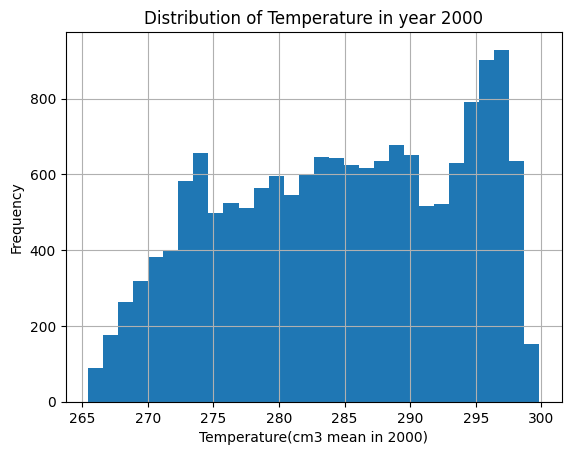

In [ ]:
#Univariate Analysis
df['cm3.mean_2000'].hist(bins=30)
plt.xlabel("Temperature(cm3 mean in 2000)") #x axis
plt.ylabel("Frequency")
plt.title("Distribution of Temperature in year 2000")
plt.show()

# Line plot-showing Temperature Change Over Years (CM3)

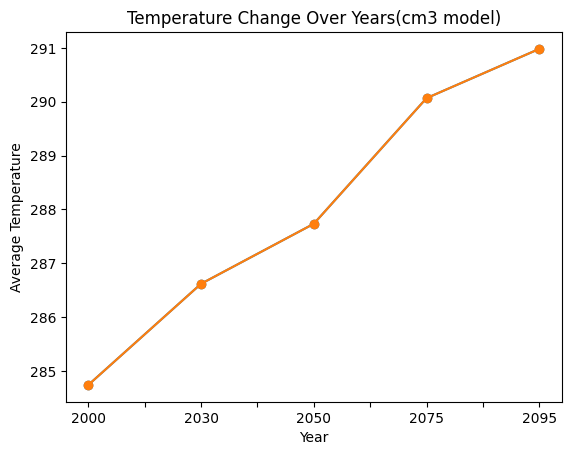

In [ ]:
# (Line Plot)showing Temperature Change Over Years (CM3)
years = ['cm3.mean_2000','cm3.mean_2030','cm3.mean_2050','cm3.mean_2075','cm3.mean_2095']

df[years].mean().plot(marker='o')

plt.xlabel("Year")
plt.ylabel("Average Temperature")
plt.title("Temperature Change Over Years(cm3 model)")



avg_temp = df[years].mean()
avg_temp.index = ['2000','2030','2050','2075','2095']
avg_temp.plot(marker='o')

plt.show()

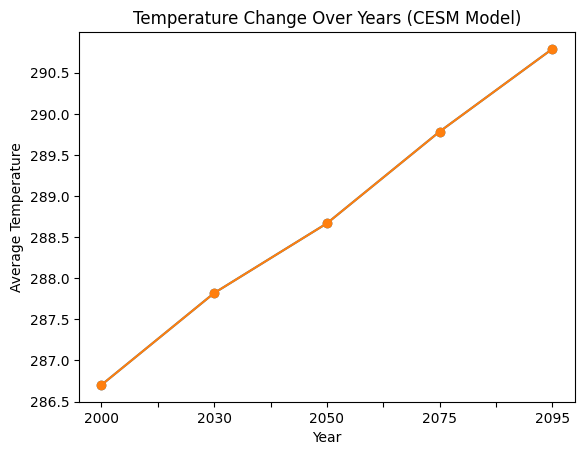

In [ ]:
# (Line Plot) showing Temperature Change Over Years (CESM)

years = ['cesm.mean_2000','cesm.mean_2030','cesm.mean_2050','cesm.mean_2075','cesm.mean_2095']

df[years].mean().plot(marker='o')

plt.xlabel("Year")
plt.ylabel("Average Temperature")
plt.title("Temperature Change Over Years (CESM Model)")

#x label change in year
avg_temp = df[years].mean()
avg_temp.index = ['2000','2030','2050','2075','2095']
avg_temp.plot(marker='o')

plt.show()

In [ ]:
cm3_mean = [
    df['cm3.mean_2000'].mean(),
    df['cm3.mean_2030'].mean(),
    df['cm3.mean_2050'].mean(),
    df['cm3.mean_2075'].mean(),
    df['cm3.mean_2095'].mean()
]

cesm_mean = [
    df['cesm.mean_2000'].mean(),
    df['cesm.mean_2030'].mean(),
    df['cesm.mean_2050'].mean(),
    df['cesm.mean_2075'].mean(),
    df['cesm.mean_2095'].mean()
]

years = [2000, 2030, 2050, 2075, 2095]

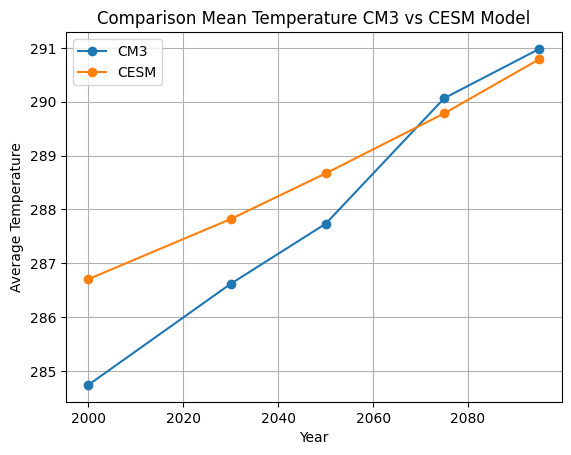

In [ ]:

plt.plot(years, cm3_mean, marker='o', label='CM3')
plt.plot(years, cesm_mean, marker='o', label='CESM')

plt.xlabel("Year")
plt.ylabel("Average Temperature")
plt.title("Comparison Mean Temperature CM3 vs CESM Model")
plt.legend()
plt.grid()

plt.show()

In [ ]:
print(df.columns)

Index(['grid_col', 'grid_row', 'cm3.mean_2000', 'cm3.mean.low_2000',
       'cm3.mean.high_2000', 'cm3.mean_2030', 'cm3.mean.low_2030',
       'cm3.mean.high_2030', 'cm3.mean_2050', 'cm3.mean.low_2050',
       'cm3.mean.high_2050', 'cm3.mean_2075', 'cm3.mean.low_2075',
       'cm3.mean.high_2075', 'cm3.mean_2095', 'cm3.mean.low_2095',
       'cm3.mean.high_2095', 'cm3.2000.t2max', 'cm3.max.low_2000_o3',
       'cm3.max.high_2000_o3', 'cm3.max_2030', 'cm3.max.low_2030_o3',
       'cm3.max.high_2030_o3', 'cm3.max_2050', 'cm3.max.low_2050_o3',
       'cm3.max.high_2050_o3', 'cm3.max_2075', 'cm3.max.low_2075_o3',
       'cm3.max.high_2075_o3', 'cm3.max_2095', 'cm3.max.low_2095_o3',
       'cm3.max.high_2095_o3', 'cesm.mean_2000', 'cesm.mean.low_2000',
       'cesm.mean.high_2000', 'cesm.mean_2030', 'cesm.mean.low_2030',
       'cesm.mean.high_2030', 'cesm.mean_2050', 'cesm.mean.low_2050',
       'cesm.mean.high_2050', 'cesm.mean_2075', 'cesm.mean.low_2075',
       'cesm.mean.high_2075', 'c

In [ ]:
cm3_max = [
    df['cm3.2000.t2max'].max(),
    df['cm3.max_2030'].max(),
    df['cm3.max_2050'].max(),
    df['cm3.max_2075'].max(),
    df['cm3.max_2095'].max()
]

cesm_max = [
    df['cesm.max_2000'].max(),
    df['cesm.max_2030'].max(),
    df['cesm.max_2050'].max(),
    df['cesm.max_2075'].max(),
    df['cesm.max_2095'].max()
]

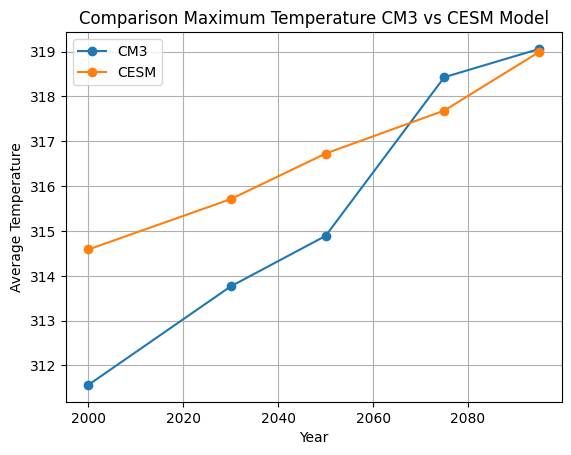

In [ ]:
plt.plot(years, cm3_max, marker='o', label='CM3')
plt.plot(years, cesm_max, marker='o', label='CESM')

plt.xlabel("Year")
plt.ylabel("Average Temperature")
plt.title("Comparison Maximum Temperature CM3 vs CESM Model")
plt.legend()
plt.grid()

plt.show()

# Trend Analysis


In [ ]:
cm3_low = [
    df['cm3.mean.low_2000'].mean(),
    df['cm3.mean.low_2000'].mean(),
    df['cm3.mean.low_2050'].mean(),
    df['cm3.mean.low_2075'].mean(),
    df['cm3.mean.low_2095'].mean()
]

cm3_high = [
    df['cm3.mean.high_2000'].mean(),
    df['cm3.mean.high_2030'].mean(),
    df['cm3.mean.high_2050'].mean(),
    df['cm3.mean.high_2075'].mean(),
    df['cm3.mean.high_2095'].mean()
]

cesm_low = [
    df['cesm.mean.low_2000'].mean(),
    df['cesm.mean.low_2030'].mean(),
    df['cesm.mean.low_2050'].mean(),
    df['cesm.mean.low_2075'].mean(),
    df['cesm.mean.low_2095'].mean()
]

cesm_high = [
    df['cesm.mean.high_2000'].mean(),
    df['cesm.mean.high_2030'].mean(),
    df['cesm.mean.high_2050'].mean(),
    df['cesm.mean.high_2075'].mean(),
    df['cesm.mean.high_2095'].mean()
]

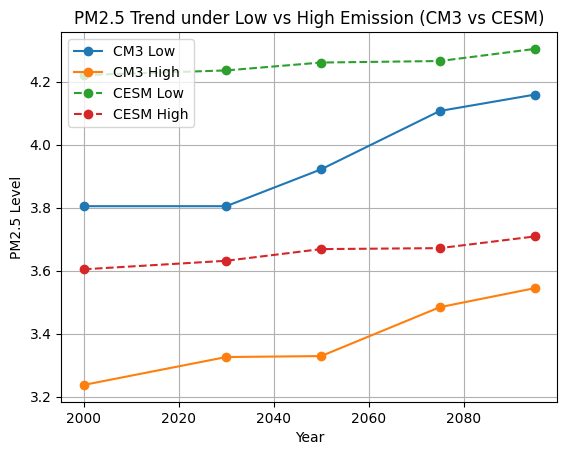

In [ ]:
#CM3
plt.plot(years, cm3_low, marker='o', label='CM3 Low')
plt.plot(years, cm3_high, marker='o', label='CM3 High')

# CESM
plt.plot(years, cesm_low, marker='o', linestyle='--', label='CESM Low')
plt.plot(years, cesm_high, marker='o', linestyle='--', label='CESM High')

plt.xlabel("Year")
plt.ylabel("PM2.5 Level")
plt.title("PM2.5 Trend under Low vs High Emission (CM3 vs CESM)")
plt.legend()
plt.grid()

plt.show()

In [ ]:
cm3_mlow = [
    df['cm3.max.low_2000_o3'].max(),
    df['cm3.max.low_2030_o3'].max(),
    df['cm3.max.low_2050_o3'].max(),
    df['cm3.max.low_2075_o3'].max(),
    df['cm3.max.low_2095_o3'].max()
]

cm3_mhigh = [
    df['cm3.max.high_2000_o3'].max(),
    df['cm3.max.high_2030_o3'].max(),
    df['cm3.max.high_2050_o3'].max(),
    df['cm3.max.high_2075_o3'].max(),
    df['cm3.max.high_2095_o3'].max()
]

cesm_mlow = [
    df['cesm.max.low_2000_o3'].max(),
    df['cesm.max.low_2030_o3'].max(),
    df['cesm.max.low_2050_o3'].max(),
    df['cesm.max.low_2075_o3'].max(),
    df['cesm.max.low_2095_o3'].max()
]

cesm_mhigh = [
    df['cesm.max.high_2000_o3'].max(),
    df['cesm.max.high_2030_o3'].max(),
    df['cesm.max.high_2075_o3'].max(),
    df['cesm.max.high_2075_o3'].max(),
    df['cesm.max.high_2095_o3'].max()
]

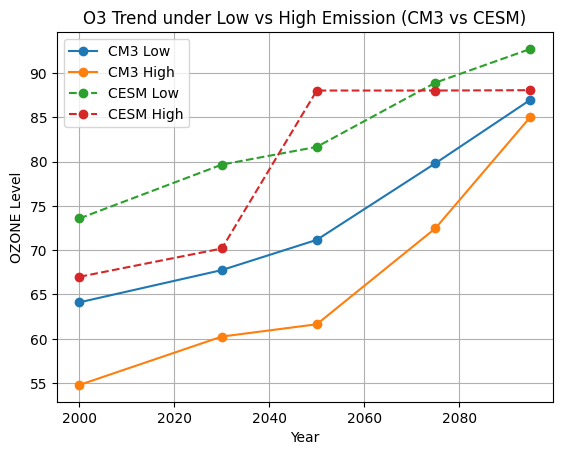

In [ ]:
#CM3
plt.plot(years, cm3_mlow, marker='o', label='CM3 Low')
plt.plot(years, cm3_mhigh, marker='o', label='CM3 High')

# CESM
plt.plot(years, cesm_mlow, marker='o', linestyle='--', label='CESM Low')
plt.plot(years, cesm_mhigh, marker='o', linestyle='--', label='CESM High')

plt.xlabel("Year")
plt.ylabel("OZONE Level")
plt.title("O3 Trend under Low vs High Emission (CM3 vs CESM)")
plt.legend()
plt.grid()

plt.show()

#Relationship Analysis

In [ ]:
#for CESM PM2.5 VS YEAR
years = ['2000','2030','2050','2075','2095']
pm_cols = [f'cesm.mean_{y}' for y in years] #cesm mean col (PM2.5 use )

plt.plot(years,df[pm_cols].mean().values,marker='o')
plt.xlabel("Year")
plt.ylabel("pm2.5 level")
plt.title("PM2.5 Trend Over Time(CESM)")
plt.grid(True)
plt.show()


# Temperature VS  pollution

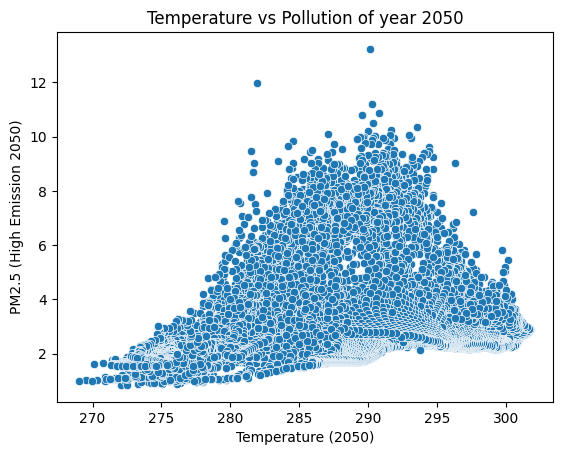

In [ ]:
sns.scatterplot(
    x=df['cm3.mean_2050'],
    y=df['cm3.mean.high_2050']
)

plt.xlabel("Temperature (2050)")
plt.ylabel("PM2.5 (High Emission 2050)")
plt.title("Temperature vs Pollution of year 2050")
plt.show()

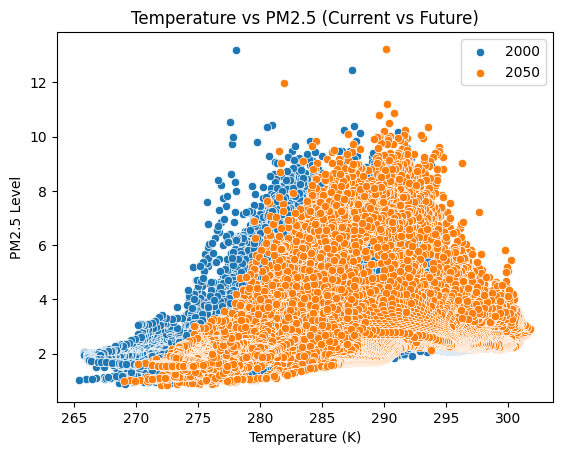

In [ ]:
# Current
sns.scatterplot(
    x=df['cm3.mean_2000'],
    y=df['cm3.mean.high_2000'],
    label='2000'
)

# Future
sns.scatterplot(
    x=df['cm3.mean_2050'],
    y=df['cm3.mean.high_2050'],
    label='2050'
)

plt.xlabel("Temperature (K)")
plt.ylabel("PM2.5 Level")
plt.legend()
plt.title("Temperature vs PM2.5 (Current vs Future)")
plt.show()

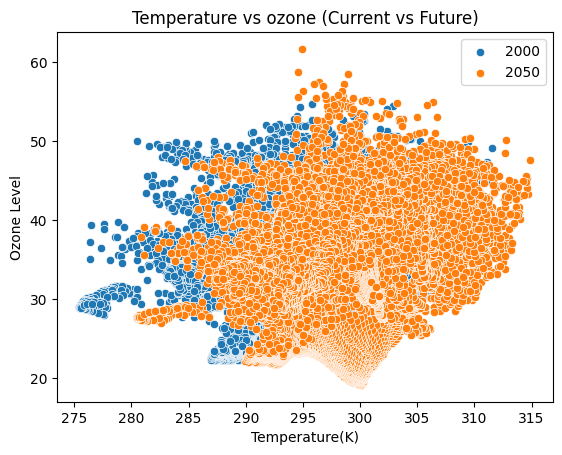

In [ ]:
# Current
sns.scatterplot(
    x=df['cm3.2000.t2max'],
    y=df['cm3.max.high_2000_o3'],
    label='2000'
)

# Future
sns.scatterplot(
    x=df['cm3.max_2050'],
    y=df['cm3.max.high_2050_o3'],
    label='2050'
)

plt.xlabel("Temperature(K)")
plt.ylabel("Ozone Level")
plt.legend()
plt.title("Temperature vs ozone (Current vs Future)")
plt.show()

In [ ]:
#Temperature VS Ozone(CESM MODEL)

import seaborn as sns

sns.scatterplot(
    x=df['cesm.mean_2000'],
    y=df['cesm.max.low_2000_o3']
)

plt.xlabel("Temperature (CESM)")
plt.ylabel("Ozone Level")
plt.title("Temperature vs Ozone(CESM)")

plt.show()


#Mean Vs Max Comparison

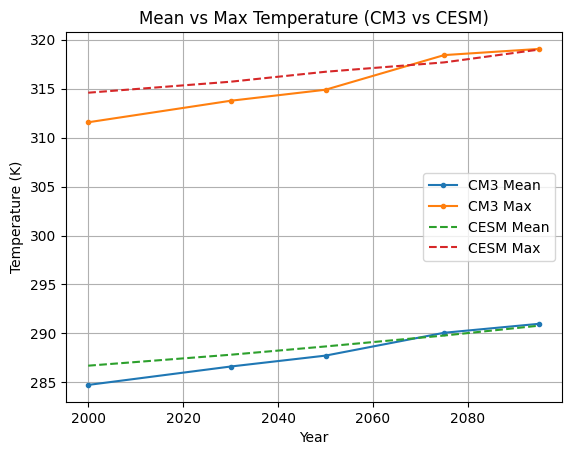

In [ ]:
plt.plot(years, cm3_mean, marker='.', label='CM3 Mean')
plt.plot(years, cm3_max, marker='.', label='CM3 Max')

plt.plot(years, cesm_mean, linestyle='--', label='CESM Mean')
plt.plot(years, cesm_max, linestyle='--', label='CESM Max')

plt.xlabel("Year")
plt.ylabel("Temperature (K)")
plt.title("Mean vs Max Temperature (CM3 vs CESM)")
plt.legend()
plt.grid()
plt.show()

# CM3 Model Tem raising in Percentage

In [ ]:
#CM3 Model Temp raising in percentage
increase = [(cm3_max[i] - cm3_mean[i]) / cm3_mean[i] * 100 for i in range(len(years))]

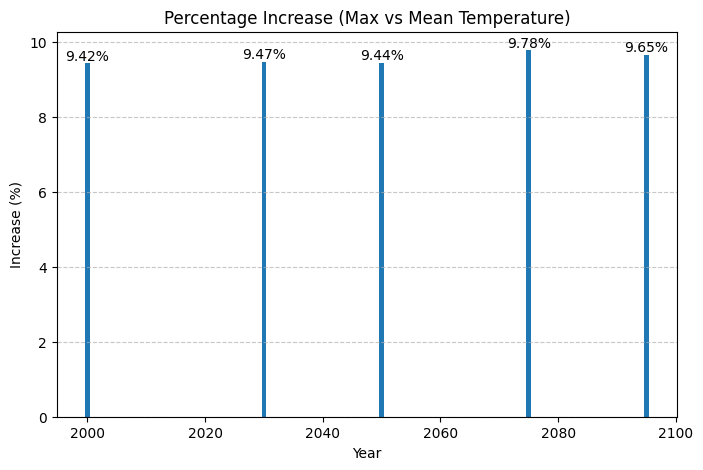

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(years, increase)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.2f}%",
             ha='center', va='bottom', fontsize=10)

plt.xlabel("Year")
plt.ylabel("Increase (%)")
plt.title("Percentage Increase (Max vs Mean Temperature)")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
#CESM Model Temp raising in Percentage
increase1 = [(cesm_max[i] - cesm_mean[i]) / cesm_mean[i] * 100 for i in range(len(years))]

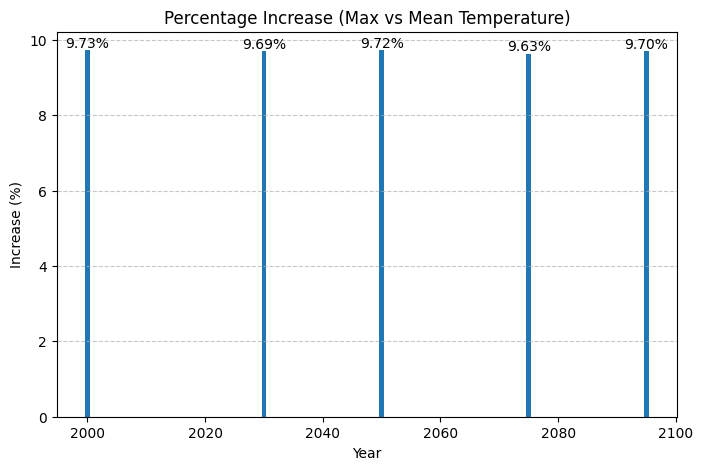

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(years, increase1)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"{y:.2f}%",
             ha='center', va='bottom', fontsize=10)

plt.xlabel("Year")
plt.ylabel("Increase (%)")
plt.title("Percentage Increase (Max vs Mean Temperature)")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# CORRELATION  HEATMAP (CESM)

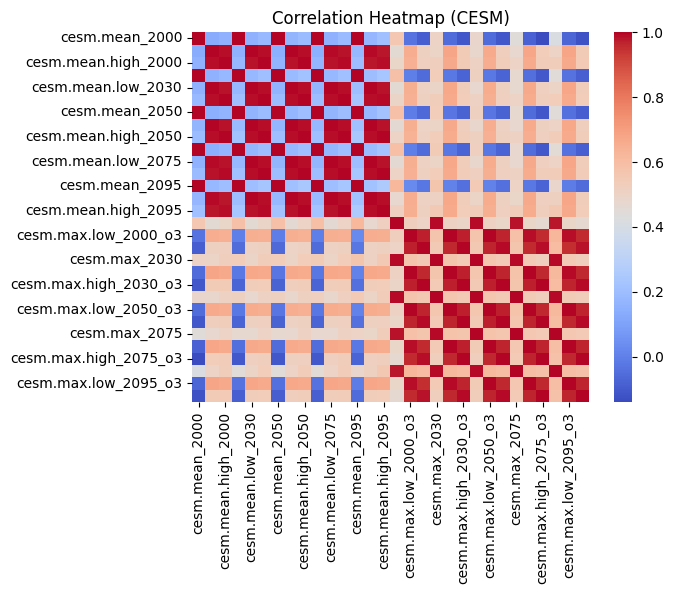

In [ ]:
import seaborn as sns

cols = [col for col in df.columns if 'cesm' in col]

corr = df[cols].corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap (CESM)")
plt.show()